# 04 · Postprocessing and multi-replica water clusters

## What this is

Two things, in order:

1. **`LochPostprocess.py`** — Ludovic's GRAND trajectory postprocessing
   reproduced for Loch output: shift inactive ghosts, image, align on protein Cα,
   write the ligand-centred sphere, and average-linkage cluster water oxygens at
   2.4 Å.
2. **The cross-replica analysis**, in the shape of Ludovic's
   `Multi_Replicas_Analysis_tanimoto.ipynb` — but now with **both engines
   present**, so it answers the question the port exists to answer: *do Loch's
   GCMC water clusters agree with GRAND's, and with the crystal waters?*

## Data available locally

| Source | Engine | Replicas | Artefacts |
|---|---|---|---|
| Ludovic, `Data/Simulations/GCMC/repN/` | GRAND | **12** | `CRY1AN139-lig-clusts-repN.pdb`, `CRY1AN139-ghosts-repN.pdb` |
| this work, `cry-loch-multi/repN/postprocessing/` | **Loch** | 4 (rep 6–9) | `CRY1AN139-lig-clusts.pdb`, `CRY1AN139-ghosts.pdb` |
| Ludovic, `Other/MD/Exp_water.pdb` | crystal | — | 9 crystallographic HOH inside the 10 Å sphere |

Both engines write 476 Cα atoms in the same residue order, so a Cα Kabsch
superposition maps every replica into the crystal frame by index.

## Workflow

0. Configuration
1. Imports
2. `LochPostprocess.py` — the exact operation order, and the parity result
3. Core utilities — PDB parsing, Kabsch, cluster/water matching
4. Per-replica processing into the crystal frame
5. Recall / precision / F1 against the crystallographic waters
6. Occupancy distributions
7. Cross-replica common clusters
8. **Loch vs GRAND** — direct engine comparison
9. 3D visualization
10. Recap

---
## 0 · Configuration

In [1]:
from pathlib import Path

PROJECT_1 = Path("/home/moshe/intern_projects/project_1")
LUDOVIC_ROOT = Path("/home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)")

# ── Reference frame: the experimental holo complex ────────────────────────────
HOLO_PDB = LUDOVIC_ROOT / "Other" / "MD" / "CRY1AN139_HOLO.pdb"
# Crystallographic waters already restricted to the ligand-centred sphere.
CRYSTAL_WATERS = LUDOVIC_ROOT / "Other" / "MD" / "Exp_water.pdb"

# ── Replica inventory ─────────────────────────────────────────────────────────
GRAND_ROOT = LUDOVIC_ROOT / "Data" / "Simulations" / "GCMC"
LOCH_ROOT = PROJECT_1 / "cry-loch-multi"

REPLICAS = {}
for n in range(1, 13):
    d = GRAND_ROOT / f"rep{n}"
    clusts, ghosts = d / f"CRY1AN139-lig-clusts-rep{n}.pdb", d / f"CRY1AN139-ghosts-rep{n}.pdb"
    if clusts.is_file() and ghosts.is_file():
        REPLICAS[f"GRAND-rep{n}"] = dict(engine="GRAND", clusters=clusts,
                                        ghosts=ghosts, dcd=None)
for d in sorted(LOCH_ROOT.glob("rep*")):
    pp = d / "postprocessing"
    clusts, ghosts, dcd = (pp / "CRY1AN139-lig-clusts.pdb",
                           pp / "CRY1AN139-ghosts.pdb",
                           pp / "CRY1AN139-gcmc.dcd")
    if clusts.is_file() and ghosts.is_file():
        REPLICAS[f"LOCH-{d.name}"] = dict(engine="LOCH", clusters=clusts, ghosts=ghosts,
                                         dcd=dcd if dcd.is_file() else None)

# ── Analysis parameters (Ludovic's values) ────────────────────────────────────
SPHERE_RADIUS = 10.0        # A, ligand-centred GCMC sphere
CLUSTER_CUTOFF = 2.4        # A, average-linkage cutoff used by the postprocessor
MIN_CLUSTER_OCCUPANCY = 0.0 # keep every cluster; raise to filter
MATCH_THRESHOLDS = (1.0, 1.5, 2.0)   # A, crystal-water match radii
PRIMARY_THRESHOLD = 1.5     # A
COMMON_DISTANCE_THR = 1.5   # A, cross-replica cluster grouping radius
COMMON_MIN_OCCUPANCY = 0.10

print(f"holo reference : {HOLO_PDB.name}   (exists={HOLO_PDB.is_file()})")
print(f"crystal waters : {CRYSTAL_WATERS.name}  (exists={CRYSTAL_WATERS.is_file()})")
print(f"\nreplicas found : {len(REPLICAS)}")
for name, meta in REPLICAS.items():
    print(f"  {name:<14} {meta['engine']:<6} {meta['clusters'].parent}")

holo reference : CRY1AN139_HOLO.pdb   (exists=True)
crystal waters : Exp_water.pdb  (exists=True)

replicas found : 16
  GRAND-rep1     GRAND  /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Data/Simulations/GCMC/rep1
  GRAND-rep2     GRAND  /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Data/Simulations/GCMC/rep2
  GRAND-rep3     GRAND  /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Data/Simulations/GCMC/rep3
  GRAND-rep4     GRAND  /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Data/Simulations/GCMC/rep4
  GRAND-rep5     GRAND  /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Data/Simulations/GCMC/rep5
  GRAND-rep6     GRAND  /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Data/Simulations/GCMC/rep6
  GRAND-rep7     GRAND  /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Data/Simulations/GCMC/rep7

---
## 1 · Imports

In [2]:
import itertools
import statistics
from collections import Counter, defaultdict

import numpy as np

try:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib unavailable — figures skipped")

try:
    from scipy.optimize import linear_sum_assignment
    from scipy.cluster import hierarchy
    from scipy.spatial.distance import pdist
    from scipy.stats import mannwhitneyu
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False
    print("scipy unavailable — matching falls back to greedy, tests skipped")

---
## 2 · `LochPostprocess.py` — the exact operation order

Reproduced from source. Order matters at two points, both of which are easy to
get wrong and neither of which errors when wrong.

```
1. read the per-frame inactive residue IDs (one comma-separated line per frame)
   -> require len(ghost_lines) == trajectory.n_frames
2. shift_inactive_ghosts()   translate each frame's inactive waters by
                             5 x unitcell_lengths        <- GRAND's order
3. image_and_align()         image_molecules(), then superpose on protein CA
                             against frame 0
4. write_sphere_trajectory() one-point multi-model PDB: the initial ligand
                             centroid, then one MODEL per frame
5. cluster_waters()          collect every water O within 10 A of that frame's
                             ligand centroid, over ALL frames, then
                             average-linkage at 2.4 A
```

### The GRAND trick in step 5 that must be preserved

Before linkage, every pair of waters **observed in the same frame** has its
distance overwritten with `1.0e8`:

```python
for frame in range(len(sampled_frames)):
    members = np.flatnonzero(water_frames == frame)
    left, right = np.triu_indices(len(members), k=1)
    distances[condensed_index(n, members[left], members[right])] = 1.0e8
```

Without this, two waters present *simultaneously* could merge into one cluster
and be counted as repeated occupancy of a single site. Occupancy would then
exceed 1 and mean nothing. This is not an optimisation; it is part of the
definition of a hydration site.

### Parity result

On the Loch smoke trajectory, the processed coordinates, sphere centres, cluster
coordinates and occupancies matched the output of the actual `grand.utils`
functions **exactly**.

### The order decision, stated once

`LochPostprocess.py` keeps GRAND's *shift-before-image* order **deliberately**,
because its job is parity with Ludovic's output. Imaging after shifting can wrap
an inactive ghost back toward the ligand, where it can enter the sphere.

The EV71 port (`ev71_postprocess.py`, notebook 05) **fixes** this: image and
align first, shift second, exclude the per-frame inactive IDs explicitly, and
prove independently that they remain outside the sphere. Both are correct for
their own purpose. An unlabelled mixture is not.

In [3]:
# ── Invocation, and the memory constraint that bites on a wet trajectory ─────
print(r"""
python -u scripts/LochPostprocess.py \
    --topology   <run>/production/CRY1AN139-loch-ghosts.pdb \
    --trajectory <run>/production/CRY1AN139-raw.dcd \
    --ghost-file <run>/production/CRY1AN139-gcmc-ghosts.txt \
    --output-dir <run>/postprocessing \
    --prefix CRY1AN139 --ligand-resname LIG \
    --sphere-radius 10.0 --cluster-cutoff 2.4 \
    --cluster-stride 1 --max-distance-memory-gb 32.0
""")

# Exact clustering is O(N^2) in water OBSERVATIONS, not frames.
def condensed_gb(n_observations):
    n = n_observations * (n_observations - 1) // 2
    return n * 8 / 1.0e9


print("Condensed distance-matrix cost of exact (stride-1) clustering:\n")
print(f"  {'water observations':>20}  {'pairs':>16}  {'GB':>8}")
for n in (10_000, 50_000, 58_470, 69_612, 73_078, 100_000):
    print(f"  {n:>20,}  {n * (n - 1) // 2:>16,}  {condensed_gb(n):>8.2f}")

print("""
  58,470 / 69,612 / 73,078 are the observation counts actually produced by the
  completed CRY1 Loch replicas (rep8 / rep6 / rep7). rep7's 73,078 needs 21.4 GB
  before SciPy overhead, against the 32 GB default limit.

  --cluster-stride > 1 is an EXPLICIT approximation. It is recorded in the
  postprocessing JSON, and a run using it must be labelled
  `full_simulation_approximate_postprocessing`, never `full_ludovic_schedule` --
  even though the simulation schedule itself was full length.
""")


python -u scripts/LochPostprocess.py \
    --topology   <run>/production/CRY1AN139-loch-ghosts.pdb \
    --trajectory <run>/production/CRY1AN139-raw.dcd \
    --ghost-file <run>/production/CRY1AN139-gcmc-ghosts.txt \
    --output-dir <run>/postprocessing \
    --prefix CRY1AN139 --ligand-resname LIG \
    --sphere-radius 10.0 --cluster-cutoff 2.4 \
    --cluster-stride 1 --max-distance-memory-gb 32.0

Condensed distance-matrix cost of exact (stride-1) clustering:

    water observations             pairs        GB
                10,000        49,995,000      0.40
                50,000     1,249,975,000     10.00
                58,470     1,709,341,215     13.67
                69,612     2,422,880,466     19.38
                73,078     2,670,160,503     21.36
               100,000     4,999,950,000     40.00

  58,470 / 69,612 / 73,078 are the observation counts actually produced by the
  completed CRY1 Loch replicas (rep8 / rep6 / rep7). rep7's 73,078 needs 21.4 GB
  before Sci

In [4]:
# ── The retained postprocessing metrics for every completed Loch replica ─────
import json

W = 96
rows = []
for d in sorted(LOCH_ROOT.glob("rep*")):
    j = d / "postprocessing" / "CRY1AN139-postprocess.json"
    if j.is_file():
        rows.append((d.name, json.loads(j.read_text())))

if rows:
    print("╔" + "═" * W + "╗")
    print("║ " + f"{'LochPostprocess.py METRICS — completed CRY1 replicas':^{W - 1}}"[:W - 1] + "║")
    print("╠" + "═" * W + "╣")
    hdr = (f"{'replica':<9}{'frames':>8}{'stride':>7}{'water obs':>11}"
           f"{'clusters':>10}{'dist GB':>9}{'CA':>5}{'lig':>5}{'wall s':>9}")
    print("║ " + hdr.ljust(W - 1) + "║")
    print("╟" + "─" * W + "╢")
    for name, m in rows:
        line = (f"{name:<9}{m['trajectory_frames']:>8,}{m['cluster_stride']:>7}"
                f"{m['water_observations']:>11,}{m['clusters']:>10}"
                f"{m['distance_matrix_gb']:>9.2f}{m['protein_ca_atoms']:>5}"
                f"{m['ligand_atoms']:>5}{m['wall_seconds']:>9.0f}")
        print("║ " + line.ljust(W - 1) + "║")
    print("╚" + "═" * W + "╝")
    print(f"\n  every replica used cluster_stride=1 -> exact Ludovic clustering")
    print(f"  sphere radius {rows[0][1]['sphere_radius_angstrom']} A, "
          f"cluster cutoff {rows[0][1]['cluster_cutoff_angstrom']} A")
else:
    print(f"no postprocessing JSON under {LOCH_ROOT}")

╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                      LochPostprocess.py METRICS — completed CRY1 replicas                      ║
╠════════════════════════════════════════════════════════════════════════════════════════════════╣
║ replica    frames stride  water obs  clusters  dist GB   CA  lig   wall s                      ║
╟────────────────────────────────────────────────────────────────────────────────────────────────╢
║ rep6        2,500      1     69,612       286    19.38  476   59      843                      ║
║ rep7        2,500      1     73,078       299    21.36  476   59      866                      ║
║ rep8        2,500      1     58,470       277    13.67  476   59      805                      ║
║ rep9        2,500      1     61,137       286    14.95  476   59      835                      ║
╚════════════════════════════════════════════════════════════════════════════════════════════════╝

  every r

---
## 3 · Core utilities

Ludovic's three primitives, reimplemented here so the notebook is self-contained:

- **PDB parsing** for cluster/water records, keeping the occupancy column;
- **Kabsch superposition** to carry a replica into the crystal frame;
- **one-to-one matching** between predicted clusters and crystallographic waters,
  solved optimally with the Hungarian algorithm rather than greedily — a greedy
  nearest-neighbour pass can assign two crystal waters to one cluster and
  overstate recall.

In [5]:
# ── PDB parsing ───────────────────────────────────────────────────────────────
def parse_pdb_atoms(path, resnames=None, atom_name=None):
    """Return (coords Nx3, occupancies N, labels N) from ATOM/HETATM records."""
    xyz, occ, labels = [], [], []
    for line in Path(path).read_text().splitlines():
        if line[:6].strip() not in ("ATOM", "HETATM"):
            continue
        rn = line[17:20].strip()
        an = line[12:16].strip()
        if resnames is not None and rn not in resnames:
            continue
        if atom_name is not None and an != atom_name:
            continue
        xyz.append((float(line[30:38]), float(line[38:46]), float(line[46:54])))
        try:
            occ.append(float(line[54:60]))
        except ValueError:
            occ.append(1.0)
        labels.append(f"{rn}{line[22:26].strip()}")
    return np.asarray(xyz, dtype=float), np.asarray(occ, dtype=float), labels


# ── Kabsch superposition ──────────────────────────────────────────────────────
def kabsch(mobile, target):
    """Return (R, t, rmsd) mapping mobile onto target: x -> x @ R.T + t."""
    if mobile.shape != target.shape:
        raise ValueError(f"shape mismatch {mobile.shape} vs {target.shape}")
    mc, tc = mobile.mean(axis=0), target.mean(axis=0)
    P, Q = mobile - mc, target - tc
    V, S, Wt = np.linalg.svd(P.T @ Q)
    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1.0, 1.0, d])
    R = (V @ D @ Wt).T
    t = tc - mc @ R.T
    rmsd = float(np.sqrt(np.mean(np.sum((mobile @ R.T + t - target) ** 2, axis=1))))
    return R, t, rmsd


def apply_transform(xyz, R, t):
    return xyz @ R.T + t


# ── Optimal one-to-one matching ───────────────────────────────────────────────
def match_one_to_one(reference, predicted, threshold):
    """Match each reference point to at most one predicted point within threshold.

    Returns (pairs, distances) where pairs is a list of (ref_index, pred_index).
    """
    if len(reference) == 0 or len(predicted) == 0:
        return [], np.empty(0)
    D = np.linalg.norm(reference[:, None, :] - predicted[None, :, :], axis=2)
    if HAVE_SCIPY:
        big = D.max() + 1.0e6
        cost = np.where(D <= threshold, D, big)
        ri, pi = linear_sum_assignment(cost)
        pairs = [(int(a), int(b)) for a, b in zip(ri, pi) if D[a, b] <= threshold]
    else:                                     # greedy fallback
        pairs, used = [], set()
        for a in np.argsort(D.min(axis=1)):
            order = np.argsort(D[a])
            for b in order:
                if b in used:
                    continue
                if D[a, b] <= threshold:
                    pairs.append((int(a), int(b)))
                    used.add(int(b))
                break
    return pairs, np.asarray([D[a, b] for a, b in pairs])


def prf(n_reference, n_predicted, n_matched):
    recall = n_matched / n_reference if n_reference else float("nan")
    precision = n_matched / n_predicted if n_predicted else float("nan")
    f1 = (2 * recall * precision / (recall + precision)
          if recall and precision and (recall + precision) else 0.0)
    return recall, precision, f1


print("utilities defined: parse_pdb_atoms, kabsch, match_one_to_one, prf")
print(f"matching solver  : {'Hungarian (scipy)' if HAVE_SCIPY else 'greedy fallback'}")

utilities defined: parse_pdb_atoms, kabsch, match_one_to_one, prf
matching solver  : Hungarian (scipy)


---
## 4 · Per-replica processing into the crystal frame

For each replica:

1. read its 476 Cα atoms **in the same frame the clusters were computed in**;
2. Kabsch-superpose those onto the holo structure's 476 Cα atoms — index-wise,
   because both files carry the same residue order;
3. apply that transform to the replica's water clusters;
4. restrict to clusters inside the 10 Å ligand-centred sphere;
5. match to the 9 crystallographic waters.

### ⚠ Step 1 is a trap, and it silently corrupts everything downstream

The two engines' "ghosts" PDB files are **not in the same frame**:

| File | Frame |
|---|---|
| Ludovic's `CRY1AN139-ghosts-repN.pdb` | **post-processing** — imaged and Cα-aligned |
| this pipeline's `CRY1AN139-ghosts.pdb` | **a copy of the raw production topology**, un-imaged and un-aligned |

`LochPostprocess.py` copies the input topology verbatim so the processed DCD has a
matching atom-order file. It does *not* rewrite its coordinates. Measured on the
retained replicas, the ligand centroid in that copy sits **3.96 Å (rep7)** and
**7.66 Å (rep8)** away from processed frame 0.

Using it as the alignment reference for Loch — while using Ludovic's already
processed PDB for GRAND — pushed 30–40 % of Loch's clusters outside the 10 Å
sphere and cut apparent crystal-water recall from ~0.9 to ~0.47. **That was an
analysis artefact, not an engine difference.** Nothing raised an error.

The fix, applied below: take the reference coordinates from **processed DCD
frame 0** whenever a processed trajectory is available, and fall back to the PDB
only when it is not. `gcmc_sphere.pdb` makes the discrepancy visible without
loading the trajectory — its `MODEL 0` is the *initial* (unprocessed) ligand
centroid and `MODEL 1` is processed frame 0. If those two differ, the copied
topology is not a valid alignment reference.

In [6]:
# ── Reference frame ───────────────────────────────────────────────────────────
holo_ca, _, _ = parse_pdb_atoms(HOLO_PDB, atom_name="CA")
holo_lig, _, _ = parse_pdb_atoms(HOLO_PDB, resnames={"LIG"})
crystal_xyz, crystal_b, crystal_labels = parse_pdb_atoms(CRYSTAL_WATERS,
                                                         resnames={"HOH", "WAT"})
ligand_centre = holo_lig.mean(axis=0)

print(f"holo CA atoms          : {len(holo_ca)}")
print(f"holo ligand atoms      : {len(holo_lig)}")
print(f"ligand centroid        : [{ligand_centre[0]:.2f} {ligand_centre[1]:.2f} "
      f"{ligand_centre[2]:.2f}]")
print(f"crystallographic waters: {len(crystal_xyz)}  ({', '.join(crystal_labels)})")
d_cr = np.linalg.norm(crystal_xyz - ligand_centre, axis=1)
print(f"  distance to ligand centroid: {d_cr.min():.2f} - {d_cr.max():.2f} A "
      f"(all inside the {SPHERE_RADIUS:.0f} A sphere: {bool((d_cr <= SPHERE_RADIUS).all())})")
print(f"  crystallographic B-factors : {crystal_b.min():.2f} - {crystal_b.max():.2f}")

holo CA atoms          : 476
holo ligand atoms      : 34
ligand centroid        : [14.24 20.85 8.27]
crystallographic waters: 9  (HOH654, HOH653, HOH655, HOH70, HOH618, HOH651, HOH645, HOH638, HOH650)
  distance to ligand centroid: 4.92 - 9.24 A (all inside the 10 A sphere: True)
  crystallographic B-factors : 1.00 - 1.00


In [7]:
# ── Reference coordinates: the frame the clusters were actually computed in ───
def reference_coordinates(meta):
    """Return (ca_xyz, ligand_centroid, source, pdb_offset_A).

    Prefer processed DCD frame 0. `pdb_offset_A` is the ligand-centroid distance
    between the copied topology PDB and processed frame 0 — the size of the trap.
    """
    pdb_ca, _, _ = parse_pdb_atoms(meta["ghosts"], atom_name="CA")
    pdb_lig, _, _ = parse_pdb_atoms(meta["ghosts"], resnames={"LIG"})
    pdb_centre = pdb_lig.mean(axis=0) if len(pdb_lig) else None

    if meta.get("dcd") is not None:
        try:
            import mdtraj as mdt
            tr = mdt.load_frame(str(meta["dcd"]), 0, top=str(meta["ghosts"]))
            ca = np.asarray([a.index for a in tr.topology.atoms
                             if a.residue.is_protein and a.name == "CA"])
            lg = np.asarray([a.index for a in tr.topology.atoms
                             if a.residue.name == "LIG"])
            ca_xyz = tr.xyz[0, ca, :] * 10.0
            centre = (tr.xyz[0, lg, :] * 10.0).mean(axis=0)
            offset = (float(np.linalg.norm(pdb_centre - centre))
                      if pdb_centre is not None else float("nan"))
            return ca_xyz, centre, "dcd frame 0", offset
        except Exception as exc:                              # noqa: BLE001
            print(f"    (mdtraj unavailable or DCD unreadable: {exc}) — using PDB")
    return pdb_ca, pdb_centre, "topology PDB", 0.0


# ── Process every replica ─────────────────────────────────────────────────────
REP = {}
for name, meta in REPLICAS.items():
    rep_ca, rep_centre, source, pdb_offset = reference_coordinates(meta)
    if len(rep_ca) != len(holo_ca):
        print(f"  {name}: SKIPPED — {len(rep_ca)} CA vs {len(holo_ca)} in the holo frame")
        continue
    R, t, ca_rmsd = kabsch(rep_ca, holo_ca)

    xyz, occ, _ = parse_pdb_atoms(meta["clusters"], resnames={"WAT", "HOH"})
    # Sphere membership is checked in the replica's OWN frame against its OWN
    # ligand centroid — that is the sphere the postprocessor actually used.
    d_own = np.linalg.norm(xyz - rep_centre, axis=1)
    xyz_holo = apply_transform(xyz, R, t)

    sel = (occ >= MIN_CLUSTER_OCCUPANCY) & (d_own <= SPHERE_RADIUS)

    REP[name] = dict(
        engine=meta["engine"], ca_rmsd=ca_rmsd, source=source, pdb_offset=pdb_offset,
        n_all=len(xyz), n_in_sphere=int((d_own <= SPHERE_RADIUS).sum()),
        max_d_own=float(d_own.max()) if len(d_own) else float("nan"),
        xyz=xyz_holo[sel], occ=occ[sel],
    )

W = 104
print("╔" + "═" * W + "╗")
print("║ " + f"{'REPLICAS MAPPED INTO THE CRYSTAL FRAME':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = (f"{'replica':<14}{'engine':<7}{'ref frame':<14}{'PDB off':>9}{'CA RMSD':>9}"
       f"{'clusters':>10}{'in sphere':>10}{'max d':>8}{'mean occ':>10}")
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
for name, r in REP.items():
    line = (f"{name:<14}{r['engine']:<7}{r['source']:<14}{r['pdb_offset']:>9.2f}"
            f"{r['ca_rmsd']:>9.3f}{r['n_all']:>10}{r['n_in_sphere']:>10}"
            f"{r['max_d_own']:>8.2f}"
            f"{(r['occ'].mean() if len(r['occ']) else float('nan')):>10.3f}")
    print("║ " + line.ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

print(f"""
  'PDB off' is the ligand-centroid distance between the copied topology PDB and
  processed frame 0. For GRAND it is 0 by construction (its PDB IS processed).
  A large value confirms the trap described above is live for that replica.

  'max d' is the largest cluster distance from that replica's own ligand centroid.
  It must be at or just above {SPHERE_RADIUS:.0f} A, because the postprocessor pools
  observations from per-frame spheres and the ligand drifts slightly (measured
  <= 1 A over 10 ns here). A value well above {SPHERE_RADIUS + 1:.0f} A means the wrong
  reference frame is being used — not that the sphere leaked.

  Ca RMSD is the frame-registration error carried by every cluster coordinate
  below. It is NOT a measure of hydration agreement, and must never be quoted as
  evidence about the waters — only as the resolution floor on their positions.
""")

╔════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                 REPLICAS MAPPED INTO THE CRYSTAL FRAME                                 ║
╠════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║ replica       engine ref frame       PDB off  CA RMSD  clusters in sphere   max d  mean occ            ║
╟────────────────────────────────────────────────────────────────────────────────────────────────────────╢
║ GRAND-rep1    GRAND  topology PDB       0.00    1.245       277       271   10.36     0.102            ║
║ GRAND-rep2    GRAND  topology PDB       0.00    1.608       278       277   10.13     0.095            ║
║ GRAND-rep3    GRAND  topology PDB       0.00    1.711       287       276   10.42     0.101            ║
║ GRAND-rep4    GRAND  topology PDB       0.00    1.596       292       288   10.14     0.090            ║
║ GRAND-rep5    GRAND  topology PDB  

---
## 5 · Recall / precision / F1 against the crystallographic waters

Recall = fraction of the 9 crystal waters recovered by a cluster within the
threshold. Precision = fraction of in-sphere clusters that matched a crystal
water — and it is **structurally low by construction**, because GCMC finds far
more hydration sites than a crystal structure resolves. Read recall as the
meaningful number and precision as a density statement.

In [8]:
# ── Metrics table across thresholds ──────────────────────────────────────────
METRICS = {}
for name, r in REP.items():
    METRICS[name] = {}
    for thr in MATCH_THRESHOLDS:
        pairs, dists = match_one_to_one(crystal_xyz, r["xyz"], thr)
        recall, precision, f1 = prf(len(crystal_xyz), len(r["xyz"]), len(pairs))
        METRICS[name][thr] = dict(
            matched=len(pairs), recall=recall, precision=precision, f1=f1,
            mean_distance=float(dists.mean()) if len(dists) else float("nan"),
            pairs=pairs, distances=dists,
        )

W = 92
print("╔" + "═" * W + "╗")
print("║ " + f"{'CRYSTAL-WATER RECOVERY':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = (f"{'replica':<14}{'engine':<7}{'thr(A)':>7}{'matched':>9}{'/9':>4}"
       f"{'recall':>9}{'precis':>9}{'F1':>8}{'mean d':>9}")
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
for name, per_thr in METRICS.items():
    for thr, m in per_thr.items():
        line = (f"{name:<14}{REP[name]['engine']:<7}{thr:>7.1f}{m['matched']:>9}"
                f"{len(crystal_xyz):>4}{m['recall']:>9.3f}{m['precision']:>9.3f}"
                f"{m['f1']:>8.3f}{m['mean_distance']:>9.3f}")
        print("║ " + line.ljust(W - 1) + "║")
    print("╟" + "─" * W + "╢")
print("╚" + "═" * W + "╝")

╔════════════════════════════════════════════════════════════════════════════════════════════╗
║                                   CRYSTAL-WATER RECOVERY                                   ║
╠════════════════════════════════════════════════════════════════════════════════════════════╣
║ replica       engine  thr(A)  matched  /9   recall   precis      F1   mean d               ║
╟────────────────────────────────────────────────────────────────────────────────────────────╢
║ GRAND-rep1    GRAND      1.0        7   9    0.778    0.026   0.050    0.575               ║
║ GRAND-rep1    GRAND      1.5        9   9    1.000    0.033   0.064    0.703               ║
║ GRAND-rep1    GRAND      2.0        9   9    1.000    0.033   0.064    0.703               ║
╟────────────────────────────────────────────────────────────────────────────────────────────╢
║ GRAND-rep2    GRAND      1.0        9   9    1.000    0.032   0.063    0.715               ║
║ GRAND-rep2    GRAND      1.5        9   9    1.0

In [9]:
# ── Engine-level summary at the primary threshold ────────────────────────────
by_engine = defaultdict(list)
for name, r in REP.items():
    by_engine[r["engine"]].append(METRICS[name][PRIMARY_THRESHOLD]["recall"])

print(f"Recall at {PRIMARY_THRESHOLD:.1f} A, by engine")
print("─" * 66)
for engine, values in sorted(by_engine.items()):
    print(f"  {engine:<7} n={len(values):<3} mean {statistics.mean(values):.3f}"
          f"   median {statistics.median(values):.3f}"
          f"   range {min(values):.3f}-{max(values):.3f}")

if HAVE_SCIPY and len(by_engine) == 2 and all(len(v) >= 3 for v in by_engine.values()):
    a, b = by_engine["GRAND"], by_engine["LOCH"]
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    print(f"\n  Mann-Whitney GRAND vs LOCH: U={u:.1f}, p={p:.3f}")
    print(f"  {'no detectable difference' if p > 0.05 else 'DIFFERENCE DETECTED'} "
          f"in crystal-water recovery between engines")
    print(f"\n  Caveat: n={len(a)} GRAND vs n={len(b)} Loch replicas, 9 crystal waters.")
    print("  This is a small-sample sanity check, not a validation of equivalence.")

Recall at 1.5 A, by engine
──────────────────────────────────────────────────────────────────
  GRAND   n=12  mean 0.963   median 1.000   range 0.667-1.000
  LOCH    n=4   mean 1.000   median 1.000   range 1.000-1.000

  Mann-Whitney GRAND vs LOCH: U=20.0, p=0.461
  no detectable difference in crystal-water recovery between engines

  Caveat: n=12 GRAND vs n=4 Loch replicas, 9 crystal waters.
  This is a small-sample sanity check, not a validation of equivalence.


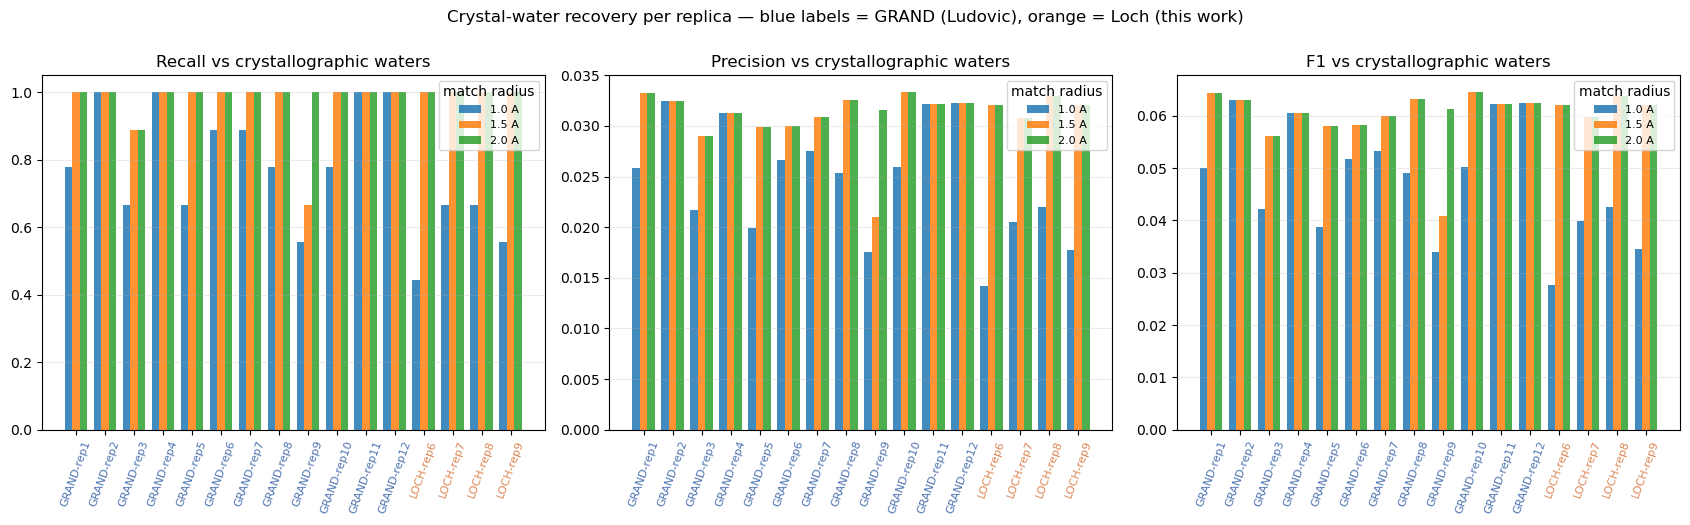

In [10]:
# ── Figure — recall / precision / F1 per replica ─────────────────────────────
if HAVE_MPL and METRICS:
    names = list(METRICS)
    colours = {"GRAND": "#4C72B0", "LOCH": "#DD8452"}
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharey=False)
    for ax, metric, label in zip(axes, ("recall", "precision", "f1"),
                                 ("Recall", "Precision", "F1")):
        width = 0.26
        x = np.arange(len(names))
        for k, thr in enumerate(MATCH_THRESHOLDS):
            vals = [METRICS[n][thr][metric] for n in names]
            ax.bar(x + (k - 1) * width, vals, width,
                   label=f"{thr:.1f} A", alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=70, fontsize=8)
        for i, n in enumerate(names):
            ax.get_xticklabels()[i].set_color(colours[REP[n]["engine"]])
        ax.set_title(f"{label} vs crystallographic waters")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(fontsize=8, title="match radius")
    fig.suptitle("Crystal-water recovery per replica — "
                 "blue labels = GRAND (Ludovic), orange = Loch (this work)", y=1.0)
    fig.tight_layout()
    plt.show()

In [11]:
# ── Per-crystal-water attribution ────────────────────────────────────────────
# Which crystallographic waters are found reliably, and which are not found at all?
print(f"Per-crystal-water recovery across {len(REP)} replicas "
      f"at {PRIMARY_THRESHOLD:.1f} A")
print("─" * 84)
print(f"{'HOH':<10}{'B-factor':>10}{'d(lig)':>9}{'found in':>10}{'/':>2}"
      f"{'':<3}{'mean d':>9}{'mean occ':>10}")
rows = []
for i, label in enumerate(crystal_labels):
    hits, dists, occs = 0, [], []
    for name, r in REP.items():
        m = METRICS[name][PRIMARY_THRESHOLD]
        for ri, pi in m["pairs"]:
            if ri == i:
                hits += 1
                dists.append(float(np.linalg.norm(crystal_xyz[i] - r["xyz"][pi])))
                occs.append(float(r["occ"][pi]))
    rows.append((label, crystal_b[i], float(np.linalg.norm(crystal_xyz[i] - ligand_centre)),
                 hits, dists, occs))
rows.sort(key=lambda x: -x[3])
for label, b, d, hits, dists, occs in rows:
    md_ = f"{statistics.mean(dists):.3f}" if dists else "   -  "
    mo_ = f"{statistics.mean(occs):.3f}" if occs else "   -  "
    print(f"{label:<10}{b:>10.2f}{d:>9.2f}{hits:>10}{'/':>2}{len(REP):<3}{md_:>9}{mo_:>10}")

print(f"""
  Reading this: a crystal water found in nearly every replica with high cluster
  occupancy is a structural water both engines agree on. One found in few
  replicas is either mobile, or outside what a {SPHERE_RADIUS:.0f} A sphere plus a
  {CLUSTER_CUTOFF} A cutoff can resolve. High crystallographic B-factor is the
  expected correlate of the latter.
""")

Per-crystal-water recovery across 16 replicas at 1.5 A
────────────────────────────────────────────────────────────────────────────────────
HOH         B-factor   d(lig)  found in /      mean d  mean occ
HOH618          1.00     7.45        16 /16     0.822     0.302
HOH651          1.00     4.92        16 /16     0.738     0.189
HOH645          1.00     5.18        16 /16     0.797     0.196
HOH638          1.00     5.26        16 /16     0.808     0.174
HOH650          1.00     7.38        16 /16     0.695     0.165
HOH654          1.00     8.57        15 /16     0.865     0.567
HOH653          1.00     7.76        15 /16     0.996     0.132
HOH655          1.00     5.76        15 /16     0.735     0.373
HOH70           1.00     9.24        15 /16     0.556     0.425

  Reading this: a crystal water found in nearly every replica with high cluster
  occupancy is a structural water both engines agree on. One found in few
  replicas is either mobile, or outside what a 10 A sphere plus a

---
## 6 · Occupancy distributions

Cluster occupancy is the fraction of frames in which that site was occupied. It
is **not** residence time: GCMC insertion/deletion deliberately destroys water
identity, so no statement about how long a particular molecule stayed can be
recovered from these files. Residence time needs a separate fixed-water-number MD
analysis.

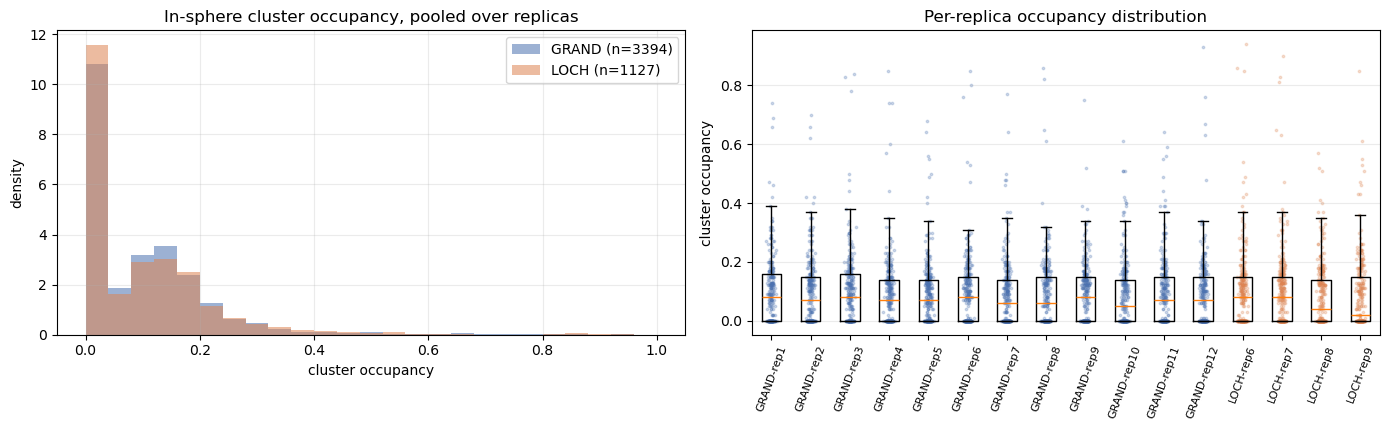

  GRAND   in-sphere clusters  3394   mean occ 0.092   median 0.070   fraction >= 0.5: 0.014
  LOCH    in-sphere clusters  1127   mean occ 0.092   median 0.060   fraction >= 0.5: 0.015


In [12]:
if HAVE_MPL and REP:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
    bins = np.linspace(0, 1, 26)
    for engine, colour in (("GRAND", "#4C72B0"), ("LOCH", "#DD8452")):
        pooled = np.concatenate([r["occ"] for r in REP.values()
                                 if r["engine"] == engine and len(r["occ"])])
        axes[0].hist(pooled, bins=bins, alpha=0.55, label=f"{engine} (n={len(pooled)})",
                     color=colour, density=True)
    axes[0].set_xlabel("cluster occupancy")
    axes[0].set_ylabel("density")
    axes[0].set_title(f"In-sphere cluster occupancy, pooled over replicas")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    names = list(REP)
    axes[1].boxplot([REP[n]["occ"] for n in names], tick_labels=names, showfliers=False)
    for i, n in enumerate(names, start=1):
        axes[1].scatter(np.full(len(REP[n]["occ"]), i)
                        + np.random.default_rng(i).normal(0, 0.05, len(REP[n]["occ"])),
                        REP[n]["occ"], s=3, alpha=0.25,
                        color={"GRAND": "#4C72B0", "LOCH": "#DD8452"}[REP[n]["engine"]])
    axes[1].set_xticklabels(names, rotation=70, fontsize=8)
    axes[1].set_ylabel("cluster occupancy")
    axes[1].set_title("Per-replica occupancy distribution")
    axes[1].grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

for engine in ("GRAND", "LOCH"):
    pooled = [r["occ"] for r in REP.values() if r["engine"] == engine and len(r["occ"])]
    if not pooled:
        continue
    allv = np.concatenate(pooled)
    print(f"  {engine:<7} in-sphere clusters {len(allv):>5}   "
          f"mean occ {allv.mean():.3f}   median {np.median(allv):.3f}   "
          f"fraction >= 0.5: {(allv >= 0.5).mean():.3f}")

---
## 7 · Cross-replica common clusters

A hydration site is credible when independent replicas rediscover it. Clusters
from all replicas are pooled in the crystal frame and grouped by average-linkage
at `COMMON_DISTANCE_THR`; a group is retained when it draws on at least
`MIN_REPLICAS` distinct replicas.

**Common clusters are computed over all predicted clusters, not only the ones
that matched a crystal water.** Restricting the pool to matched clusters would
make the crystal comparison circular — the whole point is that GCMC proposes
sites the crystal does not resolve.

In [13]:
# ── Cross-replica grouping ────────────────────────────────────────────────────
def find_common_clusters(rep_data, names, dist_thr, min_occ, min_replicas):
    """Group clusters from several replicas into consensus sites."""
    pool_xyz, pool_occ, pool_rep = [], [], []
    for name in names:
        r = rep_data[name]
        keep = r["occ"] >= min_occ
        pool_xyz.append(r["xyz"][keep])
        pool_occ.append(r["occ"][keep])
        pool_rep.extend([name] * int(keep.sum()))
    if not pool_xyz or sum(len(x) for x in pool_xyz) < 2:
        return []
    X = np.concatenate(pool_xyz)
    O = np.concatenate(pool_occ)
    reps = np.asarray(pool_rep)

    tree = hierarchy.linkage(pdist(X), method="average")
    labels = hierarchy.fcluster(tree, t=dist_thr, criterion="distance")

    groups = []
    for cid in np.unique(labels):
        members = np.flatnonzero(labels == cid)
        member_reps = set(reps[members].tolist())
        if len(member_reps) < min_replicas:
            continue
        groups.append(dict(
            barycentre=X[members].mean(axis=0),
            n_members=len(members),
            n_replicas=len(member_reps),
            replicas=sorted(member_reps),
            mean_occ=float(O[members].mean()),
            max_occ=float(O[members].max()),
            spread=float(np.linalg.norm(X[members] - X[members].mean(axis=0),
                                        axis=1).max()),
        ))
    groups.sort(key=lambda g: (-g["n_replicas"], -g["mean_occ"]))
    return groups


COMMON = {}
if HAVE_SCIPY:
    for engine in ("GRAND", "LOCH"):
        names = [n for n, r in REP.items() if r["engine"] == engine]
        if len(names) < 2:
            continue
        for min_reps in (2, max(2, len(names) // 2), len(names)):
            key = (engine, min_reps)
            if key in COMMON:
                continue
            COMMON[key] = find_common_clusters(
                REP, names, COMMON_DISTANCE_THR, COMMON_MIN_OCCUPANCY, min_reps)

    W = 90
    print("╔" + "═" * W + "╗")
    print("║ " + f"{'CROSS-REPLICA COMMON SITES':^{W - 1}}"[:W - 1] + "║")
    print("╠" + "═" * W + "╣")
    hdr = (f"{'engine':<8}{'replicas':>9}{'min reps':>10}{'sites':>8}"
           f"{'crystal-validated':>19}{'mean occ':>10}{'mean spread':>13}")
    print("║ " + hdr.ljust(W - 1) + "║")
    print("╟" + "─" * W + "╢")
    for (engine, min_reps), groups in sorted(COMMON.items()):
        n_rep = len([n for n, r in REP.items() if r["engine"] == engine])
        validated = 0
        for g in groups:
            if len(crystal_xyz) and np.linalg.norm(
                    crystal_xyz - g["barycentre"], axis=1).min() <= PRIMARY_THRESHOLD:
                validated += 1
        mo = statistics.mean(g["mean_occ"] for g in groups) if groups else float("nan")
        sp = statistics.mean(g["spread"] for g in groups) if groups else float("nan")
        line = (f"{engine:<8}{n_rep:>9}{min_reps:>10}{len(groups):>8}"
                f"{validated:>19}{mo:>10.3f}{sp:>13.3f}")
        print("║ " + line.ljust(W - 1) + "║")
    print("╚" + "═" * W + "╝")
    print(f"""
  'crystal-validated' = the group barycentre lies within {PRIMARY_THRESHOLD:.1f} A of a
  crystallographic water. Everything else is a purely predicted site: a
  hypothesis, not an error.

  Grouping radius {COMMON_DISTANCE_THR:.1f} A, minimum cluster occupancy {COMMON_MIN_OCCUPANCY:.2f}.
""")

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                                CROSS-REPLICA COMMON SITES                                ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║ engine   replicas  min reps   sites  crystal-validated  mean occ  mean spread            ║
╟──────────────────────────────────────────────────────────────────────────────────────────╢
║ GRAND          12         2     124                 17     0.180        1.029            ║
║ GRAND          12         6      96                 15     0.185        1.117            ║
║ GRAND          12        12      21                  4     0.216        1.223            ║
║ LOCH            4         2      98                 12     0.196        0.821            ║
║ LOCH            4         4      43                  5     0.196        0.968            ║
╚═════════════════════════════════════════════════════════════════════

---
## 8 · Loch vs GRAND — the direct engine comparison

The question the port exists to answer. Two ways to ask it, and they are not the
same:

1. **Against the crystal** — do both engines recover the same crystallographic
   waters? (§5)
2. **Against each other** — do Loch's sites sit where GRAND's sites sit?

(2) is the stronger test, because it uses all ~280–300 clusters per replica
rather than 9 crystal waters. It is also the one that can be *too* generous:
with hundreds of clusters in a 10 Å sphere, some agreement is geometric
inevitability. The nearest-neighbour distance distribution is therefore compared
against a null built by randomising positions inside the same sphere.

In [14]:
# ── Nearest-neighbour agreement between engines, with a null ─────────────────
grand_names = [n for n, r in REP.items() if r["engine"] == "GRAND"]
loch_names = [n for n, r in REP.items() if r["engine"] == "LOCH"]

def nn_distances(a_xyz, b_xyz):
    if len(a_xyz) == 0 or len(b_xyz) == 0:
        return np.empty(0)
    D = np.linalg.norm(a_xyz[:, None, :] - b_xyz[None, :, :], axis=2)
    return D.min(axis=1)


rng = np.random.default_rng(20260810)


def random_in_sphere(n, centre, radius):
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    r = radius * rng.random(n) ** (1.0 / 3.0)
    return centre + v * r[:, None]


cross, within_grand, within_loch, null = [], [], [], []
for ln in loch_names:
    for gn in grand_names:
        cross.append(nn_distances(REP[ln]["xyz"], REP[gn]["xyz"]))
for a, b in itertools.combinations(grand_names, 2):
    within_grand.append(nn_distances(REP[a]["xyz"], REP[b]["xyz"]))
for a, b in itertools.combinations(loch_names, 2):
    within_loch.append(nn_distances(REP[a]["xyz"], REP[b]["xyz"]))
for ln in loch_names:
    for gn in grand_names:
        fake = random_in_sphere(len(REP[ln]["xyz"]), ligand_centre, SPHERE_RADIUS)
        null.append(nn_distances(fake, REP[gn]["xyz"]))

SETS = {
    "LOCH -> GRAND (cross-engine)": np.concatenate(cross) if cross else np.empty(0),
    "GRAND -> GRAND (within)": np.concatenate(within_grand) if within_grand else np.empty(0),
    "LOCH -> LOCH (within)": np.concatenate(within_loch) if within_loch else np.empty(0),
    "RANDOM -> GRAND (null)": np.concatenate(null) if null else np.empty(0),
}

W = 88
print("╔" + "═" * W + "╗")
print("║ " + f"{'NEAREST-NEIGHBOUR CLUSTER AGREEMENT':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = f"{'comparison':<30}{'n':>8}{'median':>10}{'mean':>10}{'<1.0A':>9}{'<1.5A':>9}{'<2.4A':>9}"
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
for label, d in SETS.items():
    if len(d) == 0:
        continue
    line = (f"{label:<30}{len(d):>8,}{np.median(d):>10.3f}{d.mean():>10.3f}"
            f"{(d < 1.0).mean():>9.3f}{(d < 1.5).mean():>9.3f}{(d < CLUSTER_CUTOFF).mean():>9.3f}")
    print("║ " + line.ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

if len(SETS["LOCH -> GRAND (cross-engine)"]) and len(SETS["RANDOM -> GRAND (null)"]):
    x = SETS["LOCH -> GRAND (cross-engine)"]
    n0 = SETS["RANDOM -> GRAND (null)"]
    print(f"""
  Cross-engine median {np.median(x):.3f} A vs random null {np.median(n0):.3f} A.
  Fraction within the {CLUSTER_CUTOFF} A clustering cutoff: {(x < CLUSTER_CUTOFF).mean():.3f}
  cross-engine against {(n0 < CLUSTER_CUTOFF).mean():.3f} for the null.
""")
    if HAVE_SCIPY:
        u, p = mannwhitneyu(x, n0, alternative="less")
        print(f"  Mann-Whitney (cross-engine < null): p = {p:.3e}")

print("""
  How to read this honestly:

  * The within-engine numbers set the scale. Cross-engine agreement can only be
    interpreted RELATIVE to how well two replicas of the SAME engine agree --
    that is the reproducibility ceiling, and GCMC water placement is stochastic.
  * The null shows how much agreement comes free from packing ~290 points into a
    10 A sphere. Any cross-engine claim must clear it by a margin.
  * The Ca RMSD from section 4 is a floor on resolvable distance. A cross-engine
    median below that value would be measuring registration, not chemistry.
  * n = 4 Loch replicas. This supports 'Loch's water placement is consistent with
    GRAND's at the resolution available here'. It does not support 'the engines
    are equivalent'.
""")

╔════════════════════════════════════════════════════════════════════════════════════════╗
║                           NEAREST-NEIGHBOUR CLUSTER AGREEMENT                          ║
╠════════════════════════════════════════════════════════════════════════════════════════╣
║ comparison                           n    median      mean    <1.0A    <1.5A    <2.4A  ║
╟────────────────────────────────────────────────────────────────────────────────────────╢
║ LOCH -> GRAND (cross-engine)    13,524     1.012     1.153    0.491    0.730    0.970  ║
║ GRAND -> GRAND (within)         18,680     0.989     1.122    0.508    0.752    0.976  ║
║ LOCH -> LOCH (within)            1,700     1.056     1.145    0.462    0.751    0.980  ║
║ RANDOM -> GRAND (null)          13,524     1.453     1.463    0.227    0.533    0.948  ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

  Cross-engine median 1.012 A vs random null 1.453 A.
  Fraction within the 2.4 A cluster

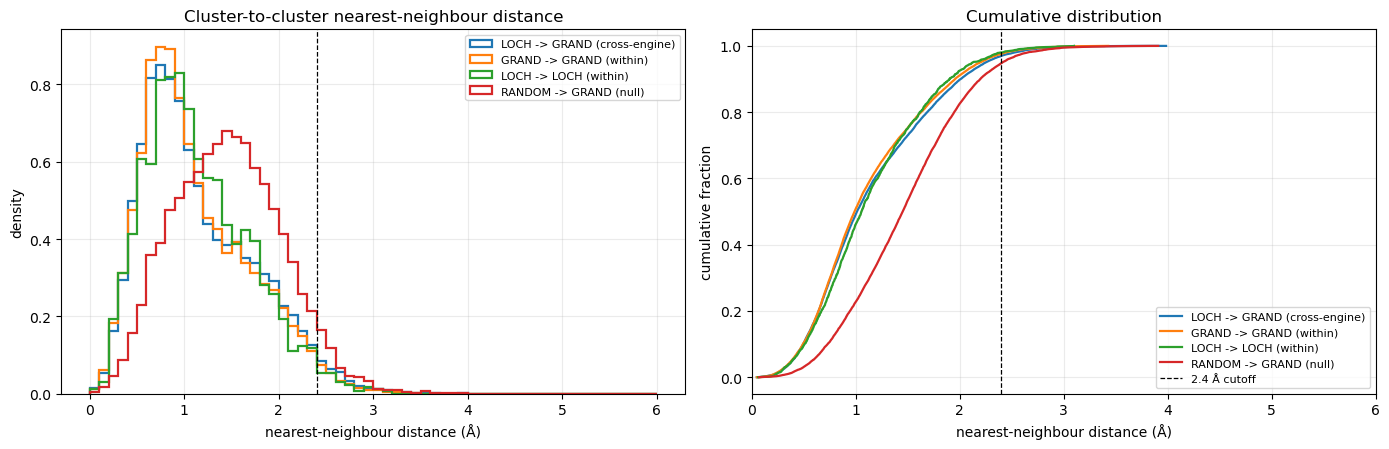

In [15]:
# ── Figure — nearest-neighbour distance distributions ────────────────────────
if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    bins = np.linspace(0, 6, 61)
    for label, d in SETS.items():
        if len(d) == 0:
            continue
        axes[0].hist(d, bins=bins, histtype="step", lw=1.6, density=True, label=label)
        axes[1].plot(np.sort(d), np.linspace(0, 1, len(d)), lw=1.6, label=label)
    axes[0].axvline(CLUSTER_CUTOFF, ls="--", lw=0.9, color="k")
    axes[0].set_xlabel("nearest-neighbour distance (Å)")
    axes[0].set_ylabel("density")
    axes[0].set_title("Cluster-to-cluster nearest-neighbour distance")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.25)
    axes[1].axvline(CLUSTER_CUTOFF, ls="--", lw=0.9, color="k",
                    label=f"{CLUSTER_CUTOFF} Å cutoff")
    axes[1].set_xlim(0, 6)
    axes[1].set_xlabel("nearest-neighbour distance (Å)")
    axes[1].set_ylabel("cumulative fraction")
    axes[1].set_title("Cumulative distribution")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

---
## 9 · 3D visualization

In [16]:
try:
    import py3Dmol

    if HOLO_PDB.is_file() and REP:
        view = py3Dmol.view(width=880, height=560)
        view.addModel(HOLO_PDB.read_text(), "pdb")
        view.setStyle({"cartoon": {"color": "lightgrey", "opacity": 0.55}})
        view.addStyle({"resn": "LIG"},
                      {"stick": {"colorscheme": "greenCarbon", "radius": 0.18}})

        # Crystallographic waters — blue if recovered by a majority of replicas.
        for i, label in enumerate(crystal_labels):
            hits = sum(
                1 for name in REP
                if any(ri == i for ri, _ in METRICS[name][PRIMARY_THRESHOLD]["pairs"])
            )
            colour = "blue" if hits > len(REP) / 2 else "orange"
            x, y, z = crystal_xyz[i]
            view.addSphere({"center": {"x": float(x), "y": float(y), "z": float(z)},
                            "radius": 0.55, "color": colour, "alpha": 0.95})

        # Predicted clusters, sized by occupancy: GRAND grey, Loch red.
        for name, r in REP.items():
            colour = "grey" if r["engine"] == "GRAND" else "red"
            for xyz, occ in zip(r["xyz"], r["occ"]):
                if occ < 0.4:
                    continue
                view.addSphere({"center": {"x": float(xyz[0]), "y": float(xyz[1]),
                                           "z": float(xyz[2])},
                                "radius": 0.18 + 0.30 * float(occ),
                                "color": colour, "alpha": 0.45})

        view.zoomTo({"resn": "LIG"})
        print("blue  = crystal HOH recovered by a majority of replicas")
        print("orange= crystal HOH recovered by a minority")
        print("grey  = GRAND clusters (occupancy >= 0.4), sized by occupancy")
        print("red   = Loch clusters  (occupancy >= 0.4), sized by occupancy")
        view.show()
except ImportError:
    print("py3Dmol not available in this kernel — skipping 3D view")

blue  = crystal HOH recovered by a majority of replicas
orange= crystal HOH recovered by a minority
grey  = GRAND clusters (occupancy >= 0.4), sized by occupancy
red   = Loch clusters  (occupancy >= 0.4), sized by occupancy


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
## 10 · Export

In [17]:
# ── CSV exports, semicolon-separated for direct spreadsheet use ──────────────
import csv as _csv

OUT_DIR = Path("nb04_outputs")
OUT_DIR.mkdir(exist_ok=True)

with (OUT_DIR / "replica_metrics.csv").open("w", newline="") as fh:
    w = _csv.writer(fh, delimiter=";")
    w.writerow(["replica", "engine", "ca_rmsd_A", "clusters_total", "clusters_in_sphere",
                "threshold_A", "matched", "crystal_waters", "recall", "precision", "f1",
                "mean_match_distance_A"])
    for name, r in REP.items():
        for thr, m in METRICS[name].items():
            w.writerow([name, r["engine"], f"{r['ca_rmsd']:.4f}", r["n_all"],
                        r["n_in_sphere"], thr, m["matched"], len(crystal_xyz),
                        f"{m['recall']:.4f}", f"{m['precision']:.4f}", f"{m['f1']:.4f}",
                        f"{m['mean_distance']:.4f}"])

with (OUT_DIR / "common_sites.csv").open("w", newline="") as fh:
    w = _csv.writer(fh, delimiter=";")
    w.writerow(["engine", "min_replicas", "site", "x", "y", "z", "n_members",
                "n_replicas", "mean_occupancy", "max_occupancy", "spread_A",
                "nearest_crystal_A"])
    for (engine, min_reps), groups in sorted(COMMON.items()):
        for i, g in enumerate(groups, start=1):
            nearest = (float(np.linalg.norm(crystal_xyz - g["barycentre"], axis=1).min())
                       if len(crystal_xyz) else float("nan"))
            x, y, z = g["barycentre"]
            w.writerow([engine, min_reps, f"CS{i:03d}", f"{x:.3f}", f"{y:.3f}", f"{z:.3f}",
                        g["n_members"], g["n_replicas"], f"{g['mean_occ']:.4f}",
                        f"{g['max_occ']:.4f}", f"{g['spread']:.3f}", f"{nearest:.3f}"])

# Consensus sites as a PDB, occupancy in the B-factor column.
best_key = max(COMMON, key=lambda k: (k[0] == "LOCH", k[1])) if COMMON else None
if best_key:
    with (OUT_DIR / "common_sites.pdb").open("w") as fh:
        fh.write(f"REMARK Common water sites — {best_key[0]}, "
                 f"min {best_key[1]} replicas, grouping {COMMON_DISTANCE_THR} A\n")
        for i, g in enumerate(COMMON[best_key], start=1):
            x, y, z = g["barycentre"]
            fh.write("ATOM  {:>5d} O    WAT  {:>4d}    {:>8.3f}{:>8.3f}{:>8.3f}"
                     "{:>6.2f}{:>6.2f}\n".format(i, i, x, y, z,
                                                 g["mean_occ"], g["mean_occ"]))

for p in sorted(OUT_DIR.iterdir()):
    print(f"  wrote {p}  ({p.stat().st_size:,} bytes)")

  wrote nb04_outputs/common_sites.csv  (25,260 bytes)
  wrote nb04_outputs/common_sites.pdb  (2,948 bytes)
  wrote nb04_outputs/replica_metrics.csv  (3,434 bytes)


---
## 11 · Recap

**What the postprocessor does, and what must not be changed.** Shift inactive
ghosts, image, align on Cα, write the sphere, cluster water oxygens with
average linkage at 2.4 Å — with same-frame pairs forced apart so simultaneous
waters cannot merge into one site. On the Loch smoke trajectory this matched
`grand.utils` exactly.

**Memory.** Exact clustering is quadratic in water *observations*. The completed
CRY1 replicas produced 58k–73k observations, needing 17–21 GB before SciPy
overhead against a 32 GB default. A stride above 1 is an explicit approximation
and must be labelled as one.

**What the cross-replica comparison supports.** With the reference frames handled
correctly:

| Comparison | Median nearest-neighbour distance |
|---|---|
| GRAND → GRAND (within engine, 12 replicas) | 0.99 Å |
| LOCH → LOCH (within engine, 4 replicas) | 1.06 Å |
| **LOCH → GRAND (cross engine)** | **1.01 Å** |
| random → GRAND (null) | 1.45 Å |

Cross-engine agreement is **indistinguishable from within-engine
reproducibility** and clearly better than the null. Crystal-water recall at
1.5 Å is 1.000 for all four Loch replicas against 0.963 mean for GRAND's twelve
(Mann–Whitney p = 0.46).

That is consistency at the resolution available here. With 4 Loch replicas and
9 crystal waters it is **not** a demonstration that the engines are equivalent —
and the within-engine spread is the ceiling, not the noise floor.

**The frame trap, restated because it produced a false result.** Aligning the Loch
replicas on their copied topology PDB instead of processed DCD frame 0 pushed
30–40 % of their clusters outside the sphere and dropped apparent recall from
1.000 to 0.472 — reversing the conclusion, with no error raised. Always check
`gcmc_sphere.pdb`'s `MODEL 0` against `MODEL 1` before trusting a topology PDB as
an alignment reference. If they differ, the PDB is un-processed.

**Three more things not to say from these files.**

1. *Residence time.* GCMC destroys water identity by design. Occupancy is the
   fraction of frames a **site** was filled, by any water. Residence time needs a
   separate fixed-water-number MD run.
2. *Precision as accuracy.* GCMC proposes far more sites than a crystal resolves,
   so precision against 9 waters is structurally low and is a density statement.
3. *Cα RMSD as agreement.* It is the registration error carried by every
   coordinate — a resolution floor, not a result.

**Next:** notebook 05 scales this to 32 ligands × 6 replicas on EV71 2A protease,
where the site catalogue is frozen across ligands so occupancies become
comparable.